In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Conv2D, Conv2DTranspose, Layer
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.losses import binary_crossentropy
from sklearn.model_selection import train_test_split

# ✅ Load Fashion-MNIST directly from Keras
from tensorflow.keras.datasets import fashion_mnist

(train_x, train_y), (val_x, val_y) = fashion_mnist.load_data()

# Normalize (0 to 1)
train_x = train_x.astype("float32") / 255.
val_x = val_x.astype("float32") / 255.

# Reshape for CNN input: (Batch, Height, Width, Channels)
train_x = train_x.reshape(-1, 28, 28, 1)
val_x = val_x.reshape(-1, 28, 28, 1)

print(f"Train shape: {train_x.shape}, Val shape: {val_x.shape}")


2026-03-25 08:38:30.769277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774427911.008037      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774427911.074042      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774427911.627969      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774427911.628042      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774427911.628046      24 computation_placer.cc:177] computation placer alr

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28, 1), Val shape: (10000, 28, 28, 1)


In [2]:
batch_size = 16
latent_dim = 2  # Keep it 2D so we can visualize it easily later

input_img = Input(shape=(28, 28, 1), name="encoder_input")

# CNN layers to extract spatial features
x = Conv2D(32, 3, padding='same', activation='relu')(input_img)
x = Conv2D(64, 3, padding='same', activation='relu', strides=(2, 2))(x) # Down to 14x14
x = Conv2D(64, 3, padding='same', activation='relu')(x)
x = Conv2D(64, 3, padding='same', activation='relu')(x)

# Save the shape for the decoder to mirror later
shape_before_flattening = K.int_shape(x)

x = Flatten()(x)
x = Dense(32, activation='relu')(x)

# Latent space parameters: Mean and Log-Variance
z_mu = Dense(latent_dim, name="z_mu")(x)
z_log_sigma = Dense(latent_dim, name="z_log_sigma")(x)

I0000 00:00:1774427936.885966      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774427936.892233      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
def sampling(args):
    z_mu, z_log_sigma = args
    epsilon = K.random_normal(shape=(K.shape(z_mu)[0], latent_dim),
                              mean=0., stddev=1.)
    # The math: z = mu + sigma * epsilon
    return z_mu + K.exp(z_log_sigma) * epsilon

# Sample the latent vector
z = Lambda(sampling, name="z_sample")([z_mu, z_log_sigma])

In [4]:
decoder_input = Input(shape=(latent_dim,), name="decoder_input")

# 1. Map latent back to the number of units before flattening
x = Dense(np.prod(shape_before_flattening[1:]), activation='relu')(decoder_input)

# 2. Reshape back to the spatial dimensions (e.g., 14, 14, 64)
x = Reshape(shape_before_flattening[1:])(x)

# 3. Use Transpose Conv layers to upsample back to 28x28
x = Conv2DTranspose(32, 3, padding='same', activation='relu', strides=(2, 2))(x)
x = Conv2D(1, 3, padding='same', activation='sigmoid', name="decoder_output")(x)

# Define the decoder model
decoder = Model(decoder_input, x, name="decoder")
decoder.summary()

# Connect the encoder's sample (z) to the decoder
z_decoded = decoder(z)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12544)          │        37,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,385 (220.25 KB)

 Trainable params: 56,385 (220.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
class CustomVariationalLayer(Layer):
    def vae_loss(self, x, z_decoded, z_mu, z_log_sigma):
        # Flatten for reconstruction
        x = K.flatten(x)
        z_decoded = K.flatten(z_decoded)

        # Reconstruction loss
        xent_loss = binary_crossentropy(x, z_decoded)

        # KL divergence
        kl_loss = -5e-4 * K.mean(
            1 + z_log_sigma - K.square(z_mu) - K.exp(z_log_sigma),
            axis=-1
        )

        return K.mean(xent_loss + kl_loss)

    def call(self, inputs):
        x, z_decoded, z_mu, z_log_sigma = inputs
        loss = self.vae_loss(x, z_decoded, z_mu, z_log_sigma)
        self.add_loss(loss)
        return x

    def compute_output_shape(self, input_shape):
        return input_shape[0]

y = CustomVariationalLayer()([input_img, z_decoded, z_mu, z_log_sigma])
vae = Model(input_img, y)
vae.compile(optimizer="rmsprop")
vae.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12544)     │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │    401,440 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mu (Dense)        │ (None, 2)         │         66 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_sigma (Dense) │ (None, 2)         │         66 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sample (Lambda)   │ (None, 2)         │          0 │ z_mu[0][0],       │
│                     │                   │            │ z_log_sigma[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 28, 28, 1) │     56,385 │ z_sample[0][0]    │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_variational… │ (None, 28, 28, 1) │          0 │ encoder_input[0]… │
│ (CustomVariational… │                   │            │ decoder[0][0],    │
│                     │                   │            │ z_mu[0][0],       │
│                     │                   │            │ z_log_sigma[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 550,629 (2.10 MB)

 Trainable params: 550,629 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
vae.fit(x=train_x, y=None,
        shuffle=True,
        epochs=20, 
        batch_size=batch_size,
        validation_data=(val_x, None))

Epoch 1/20


I0000 00:00:1774427940.603606      70 service.cc:152] XLA service 0x7a7bb8010030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774427940.603656      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774427940.603663      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774427941.074971      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


  50/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.6589

I0000 00:00:1774427944.601221      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.4013 - val_loss: 0.3427
Epoch 2/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3385 - val_loss: 0.3357
Epoch 3/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3345 - val_loss: 0.3351
Epoch 4/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3321 - val_loss: 0.3317
Epoch 5/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3298 - val_loss: 0.3309
Epoch 6/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3289 - val_loss: 0.3311
Epoch 7/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3274 - val_loss: 0.3295
Epoch 8/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3273 - val_loss: 0.3295
Epoch 9/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3256 - val_loss: 0.3283
Epoch 10/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3260 - val_loss: 0.3277
Epoch 11/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.3253 - val_loss: 0.3271
Epoch 12/20
3750/3750 ━━━━━━━━

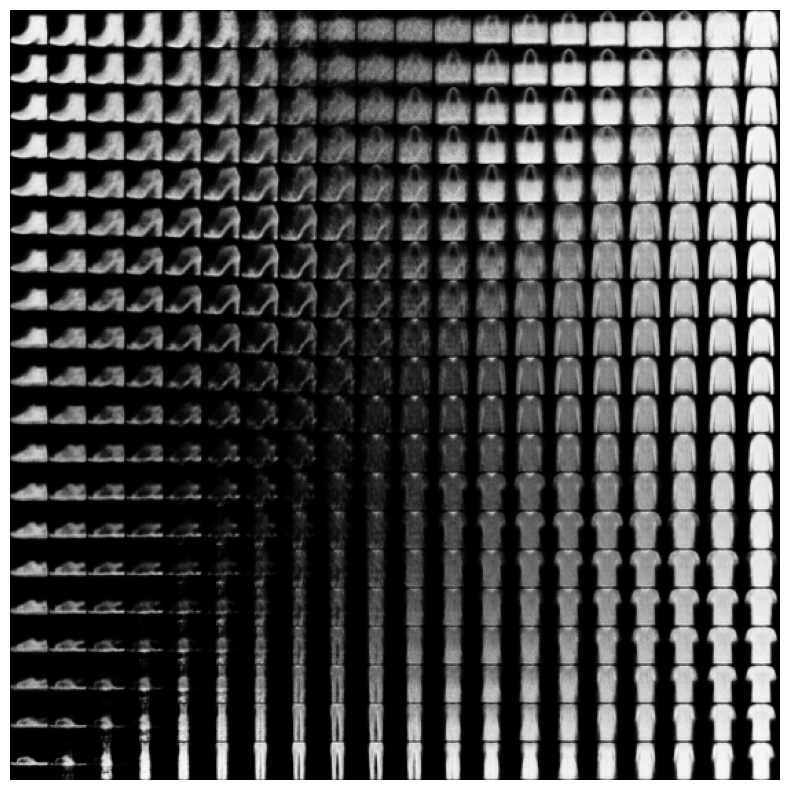

In [7]:
n = 20  # 20x20 grid of fashion items
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Linearly spaced coordinates on the unit square were transformed through 
# the inverse CDF (ppf) of the Gaussian to produce values of the latent variables
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='Greys_r')
plt.axis('off')
plt.show()

In [8]:
def build_vae(latent_dim, input_shape=(28, 28, 1)):
    # --- Encoder ---
    input_img = Input(shape=input_shape)
    x = Conv2D(32, 3, padding='same', activation='relu')(input_img)
    x = Conv2D(64, 3, padding='same', activation='relu', strides=(2, 2))(x)
    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    
    shape_before_flattening = K.int_shape(x)
    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    
    z_mu = Dense(latent_dim)(x)
    z_log_sigma = Dense(latent_dim)(x)
    
    def sampling(args):
        z_mu, z_log_sigma = args
        epsilon = K.random_normal(shape=(K.shape(z_mu)[0], latent_dim))
        return z_mu + K.exp(z_log_sigma) * epsilon
    
    z = Lambda(sampling)([z_mu, z_log_sigma])
    
    # --- Decoder ---
    decoder_input = Input(shape=(latent_dim,))
    x_dec = Dense(np.prod(shape_before_flattening[1:]), activation='relu')(decoder_input)
    x_dec = Reshape(shape_before_flattening[1:])(x_dec)
    x_dec = Conv2DTranspose(32, 3, padding='same', activation='relu', strides=(2, 2))(x_dec)
    x_dec = Conv2D(1, 3, padding='same', activation='sigmoid')(x_dec)
    
    decoder = Model(decoder_input, x_dec, name="decoder")
    z_decoded = decoder(z)
    
    # --- Loss Layer ---
    class VAE_Loss_Layer(Layer):
        def call(self, inputs):
            img, decoded, mu, log_sig = inputs
            img_flat = K.flatten(img)
            dec_flat = K.flatten(decoded)
            
            # Reconstruction (Binary Crossentropy)
            recon_loss = binary_crossentropy(img_flat, dec_flat)
            # KL Divergence
            kl_loss = -5e-4 * K.mean(1 + log_sig - K.square(mu) - K.exp(log_sig), axis=-1)
            
            total_loss = K.mean(recon_loss + kl_loss)
            self.add_loss(total_loss)
            return img

    output = VAE_Loss_Layer()([input_img, z_decoded, z_mu, z_log_sigma])
    vae = Model(input_img, output)
    vae.compile(optimizer='rmsprop')
    
    return vae, decoder

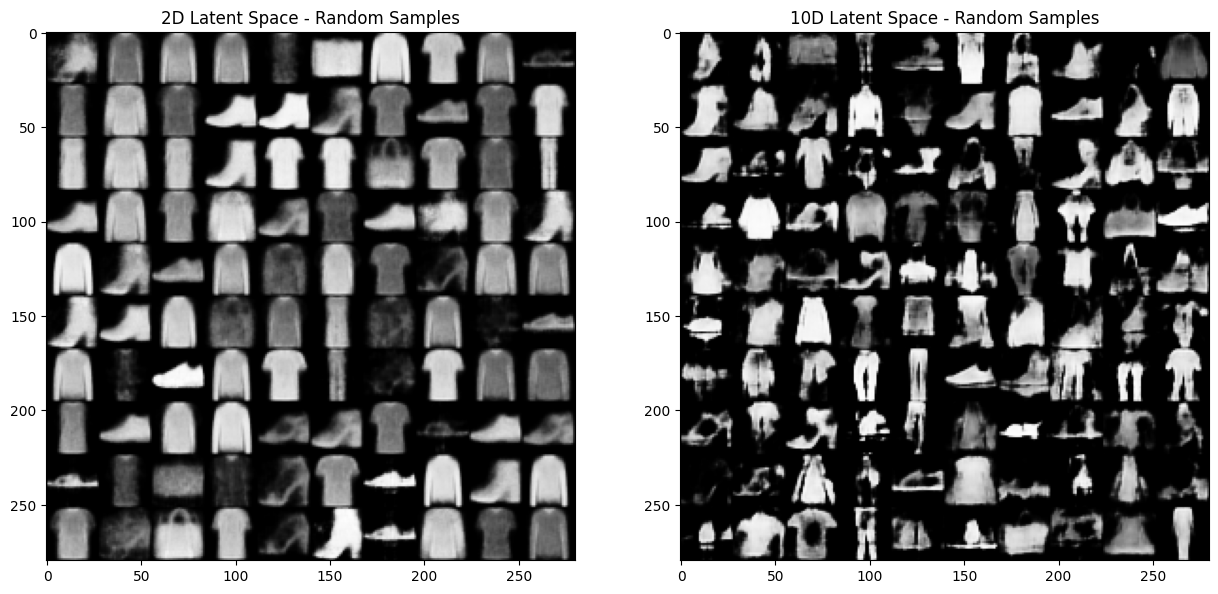

In [9]:
# Train 2D VAE
vae_2d, decoder_2d = build_vae(latent_dim=2)
vae_2d.fit(train_x, epochs=10, batch_size=16, verbose=0)

# Train 10D VAE
vae_10d, decoder_10d = build_vae(latent_dim=10)
vae_10d.fit(train_x, epochs=10, batch_size=16, verbose=0)

# Generate Random Samples for both
def get_random_grid(decoder, dim, n=10):
    z_samples = np.random.normal(size=(n*n, dim))
    decoded = decoder.predict(z_samples, verbose=0)
    grid = np.zeros((28*n, 28*n))
    for i in range(n):
        for j in range(n):
            grid[i*28:(i+1)*28, j*28:(j+1)*28] = decoded[i*n+j].reshape(28, 28)
    return grid

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(get_random_grid(decoder_2d, 2), cmap='Greys_r')
plt.title("2D Latent Space - Random Samples")
plt.subplot(1, 2, 2)
plt.imshow(get_random_grid(decoder_10d, 10), cmap='Greys_r')
plt.title("10D Latent Space - Random Samples")
plt.show()

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.3800 - val_loss: 0.2997
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2964 - val_loss: 0.2923
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2896 - val_loss: 0.2889
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2854 - val_loss: 0.2863
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2839 - val_loss: 0.2866
Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.3740 - val_loss: 0.2994
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2969 - val_loss: 0.2907
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2892 - val_loss: 0.2886
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2862 - val_loss: 0.2861
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2844 - val_loss: 0.2848
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2834 - val_loss: 0.2844
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━

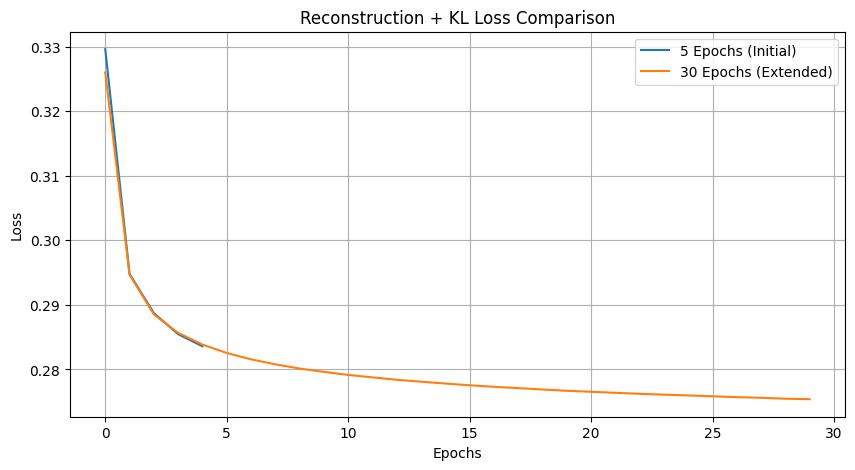

In [10]:
# Use the 10D model for this
vae_short, _ = build_vae(10)
history_5 = vae_short.fit(train_x, epochs=5, batch_size=32, validation_data=(val_x, None))

vae_long, _ = build_vae(10)
history_30 = vae_long.fit(train_x, epochs=30, batch_size=32, validation_data=(val_x, None))

# Plotting the curves
plt.figure(figsize=(10, 5))
plt.plot(history_5.history['loss'], label='5 Epochs (Initial)')
plt.plot(history_30.history['loss'], label='30 Epochs (Extended)')
plt.title("Reconstruction + KL Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step


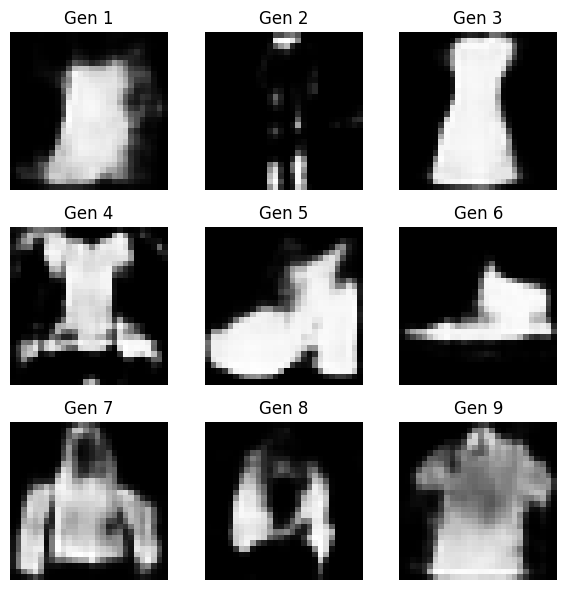

In [11]:
# Sample 9 random points in the 10D latent space
manual_latent = np.random.normal(size=(9, 10)) 

# Pass through the 10D decoder
generated_images = decoder_10d.predict(manual_latent)

# Plot in a 3x3 grid
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='Greys_r')
    plt.axis('off')
    plt.title(f"Gen {i+1}")

plt.tight_layout()
plt.show()